# 7.5.1 重要性采样与稳定权重

## 学习目标与先修知识

从期望（expectation）积分推导重要性权重，解释自归一化与提议支持条件。

先修：7.2的连续积分更新及第5篇期望、Monte Carlo均值。 [本篇学习次序](../README.md)。

## 具体问题

后验（posterior）有两个峰时，一个Gaussian不够灵活。能否用样本表示任意形状？样本来自方便抽取的分布（distribution），而非目标分布时，必须怎样纠正？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
samples=np.array([-1.,1.,2.]);target=np.array([.2,.5,.3]);proposal=np.array([.5,.25,.25]);ratio=target/proposal;weights=ratio/ratio.sum()
print('已知完整离散目标的精确均值=',target@samples,'本次提议样本的自归一化估计=',weights@samples)

已知完整离散目标的精确均值= 0.8999999999999999 本次提议样本的自归一化估计= 1.1111111111111112


## 模型假设

重要性采样（importance sampling，IS）的提议分布q能抽样且在目标有质量处为正。初步三点例把[-1,1,2]视作q的一次可能样本，每点恰出现一次；target@samples是已知完整离散目标的精确均值，比值权重是这次有限提议样本的估计，两者不要求相等，也不声称后者更准确。一般目标只需知道未归一化密度。自归一化重要性采样在有限样本下通常有偏；在适当可积性与支持条件下随样本量增加趋于目标期望。

## 数学解释与推导

通过乘除q改写
$$E_p[g(X)]=\frac{\int g(x)\tilde p(x)dx}{\int\tilde p(x)dx}=\frac{E_q[g(X)\tilde p(X)/q(X)]}{E_q[\tilde p(X)/q(X)]}.$$
对 $X_i\sim q$，令 $a_i=\tilde p(X_i)/q(X_i)$、$w_i=a_i/\sum_ja_j$，则期望近似为 $\sum_iw_ig(X_i)$。分母随机，所以不能把两个无偏均值的比误称无偏。

稳定计算时先求 $b_i=\log\tilde p(X_i)-\log q(X_i)$，再用 $e^{b_i-\max_jb_j}$ 归一化。共同平移不改权重。有效样本量（effective sample size，ESS）的常用权重指标为 $1/\sum_iw_i^2$；均匀权重给N，单点占据给1。它不检查提议漏掉的区域，也不证明样本独立或后验正确。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型（model）与当时可用的信息。

In [3]:
def particle_update(particles, weights, log_likelihoods, offset):
    scores = np.array([(-np.inf if w == 0 or value is None else math.log(w) + value)
                       for w, value in zip(weights, log_likelihoods)])
    if not np.isfinite(scores).any():
        return dict(status='impossible', weights=[], ess=0., indices=[], particles=[])
    normalized = np.exp(scores - scores.max())
    normalized /= normalized.sum()
    positions = (offset + np.arange(len(particles))) / len(particles)
    cumulative = np.cumsum(normalized); cumulative[-1] = 1.
    # 舍入可能把合法的最后位置算成 1；此时仍取最后一个粒子。
    indices = np.minimum(np.searchsorted(cumulative, positions, side='right'), len(particles) - 1)
    return dict(status='ok', weights=normalized.tolist(), ess=float(1 / np.sum(normalized ** 2)),
                indices=indices.tolist(), particles=np.array(particles)[indices].tolist())


def grid_update(mean, variance, observation, measurement_variance, lower=-6, upper=6, count=6001):
    grid = np.linspace(lower, upper, count)
    log_mass = -.5 * ((grid - mean) ** 2 / variance + (observation - grid ** 2) ** 2 / measurement_variance)
    mass = np.exp(log_mass - log_mass.max())
    density = mass / np.trapezoid(mass, grid)
    updated_mean = float(np.trapezoid(grid * density, grid))
    updated_variance = float(np.trapezoid((grid - updated_mean) ** 2 * density, grid))
    return grid, density, updated_mean, updated_variance

## 对照实验

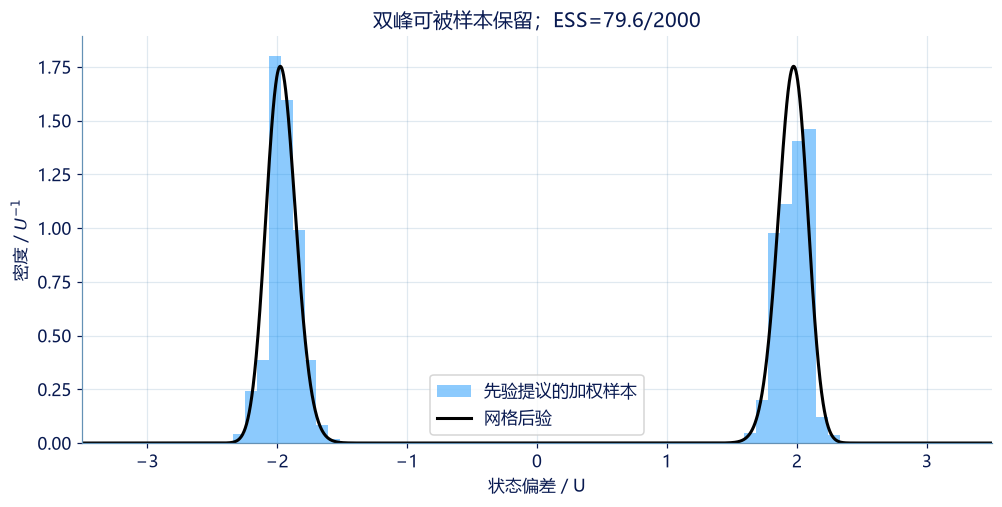

加权均值= -0.019919823887771526 网格均值= -1.1102230246251565e-16


In [4]:
rng=np.random.default_rng(715);N=2000;particles=rng.normal(0,1,N);y=4.;R=.2
log_likelihood=-.5*(y-particles**2)**2/R
updated=particle_update(particles,np.ones(N)/N,log_likelihood,.5)
grid,density,gm,gp=grid_update(0,1,y,R)
fig,ax=plt.subplots(figsize=(9,4.5));ax.hist(particles,bins=70,weights=updated['weights'],density=True,alpha=.45,label='先验提议的加权样本');ax.plot(grid,density,'k-',label='网格后验');ax.set(xlim=(-3.5,3.5),xlabel='状态偏差 / U',ylabel='密度 / $U^{-1}$',title=f'双峰可被样本保留；ESS={updated["ess"]:.1f}/{N}');ax.legend();plt.show()
print('加权均值=',np.array(updated['weights'])@particles,'网格均值=',gm)

### 独立核验与边界

In [5]:
shifted=particle_update(particles,np.ones(N)/N,log_likelihood-10000,.5)
np.testing.assert_allclose(shifted['weights'],updated['weights'],atol=1e-12)
assert 1<=updated['ess']<=N+1e-10
uniform=particle_update([-1,0,1],[1/3]*3,[0,0,0],.5);np.testing.assert_allclose(uniform['ess'],3)
impossible=particle_update([0,1],[.5,.5],[None,None],.5);assert impossible['status']=='impossible'
print('对数平移、均匀边界和零质量分支核验通过；2000个样本仍是有限近似。')

对数平移、均匀边界和零质量分支核验通过；2000个样本仍是有限近似。


## 结果解释

先验（prior）提议有许多样本落在读数不支持的中心附近，所以权重集中、ESS远小于名义样本数。图中的两峰来自同一观测（observation）的符号歧义；若提议只覆盖正半轴，调整已有权重也无法恢复负峰。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：稳定计算重要性权重

给定已由提议分布（distribution）q抽取的样本及其目标密度和提议密度的对数值。计算自归一化权重、状态（state）均值和有效样本量。

**函数与代码模板**

```python
def solve(
    samples: list[float],
    log_target: list[float],
    log_proposal: list[float],
) -> tuple[list[float], float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `samples` | `list[float]` | 由q抽取的样本。 | U |
| `log_target` | `list[float]` | 未归一化目标密度的对数值。 | 无量纲 |
| `log_proposal` | `list[float]` | 提议密度的对数值。 | 无量纲 |

**返回值**

按以下顺序返回元组：(weights, mean, ess)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `weights` | `list[float]` | 归一化的重要性权重。 | 概率 |
| `mean` | `float` | 按权重求得的状态均值。 | U |
| `ess` | `float` | 1/sum(w²)。 | 个 |

**计算规则**

log_weight=log_target−log_proposal；先减去最大log_weight再取指数并归一化。不得只用目标密度作为权重。

**约束与边界**

- 三个列表等长，1—100项；对数值有限，绝对值≤10000。
- 本题给定样本上q均非零；总体提议支持应覆盖目标支持。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| samples | 由q抽取的样本。 | [-1.0, 1.0, 2.0] | U |
| log_target | 未归一化目标密度的对数值。 | [-1.6094379124341003, -0.6931471805599453, -1.2039728043259361] | 无量纲 |
| log_proposal | 提议密度的对数值。 | [-0.6931471805599453, -1.3862943611198906, -1.3862943611198906] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
samples = [-1.0, 1.0, 2.0]
log_target = [-1.6094379124341003,
              -0.6931471805599453,
              -1.2039728043259361]
log_proposal = [-0.6931471805599453,
                -1.3862943611198906,
                -1.3862943611198906]

result = solve(samples, log_target, log_proposal)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| weights | 归一化的重要性权重。 | [0.11111111111111113, 0.5555555555555556, 0.3333333333333333] | 概率 |
| mean | 按权重求得的状态均值。 | ≈ 1.111111 | U |
| ess | 1/sum(w²)。 | ≈ 2.314286 | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.11111111111111113,
                    0.5555555555555556,
                    0.3333333333333333],
                   1.1111111111111112,
                   2.314285714285714)
```

**样例解释**

未归一化权重为[0.4,2,1.2]，总和3.6，状态均值约1.111111，ESS约2.314286。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：稳定计算重要性权重](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-importance-weights)

### 第 2 题 · 单项选择题：提议分布漏掉一侧

目标密度在x<0和x>0均非零，但提议分布（distribution）只在x>0生成样本。哪项正确？

- **A.** 增加权重可恢复所有负侧样本。
- **B.** 增加相同提议的样本数就消除支持遗漏。
- **C.** 目标支持未被覆盖，重要性近似不能恢复缺失区域。
- **D.** 权重均匀即可证明无偏。

[作答：提议分布漏掉一侧](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-proposal-support)

### 第 3 题 · 多项选择题：自归一化为何实用

目标只知道未归一化密度p̃，常数未知。哪些正确？

- **A.** 权重归一化可抵消相同常数。
- **B.** 有限样本的自归一化均值一般有偏。
- **C.** 样本相关性或支持缺口不影响有效性。
- **D.** 不能把ESS当作后验（posterior）正确性的证明。

[作答：自归一化为何实用](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-self-normalized)

### 第 4 题 · 单项选择题：为什么减最大对数权重

所有对数权重都加上同一常数后，哪项不变？

- **A.** 未归一化指数值。
- **B.** 归一化权重和ESS。
- **C.** 浮点下溢风险必定不变。
- **D.** 每个对数权重本身。

[作答：为什么减最大对数权重](http://127.0.0.1:8000/chapters/07-05-%E7%B2%92%E5%AD%90%E6%BB%A4%E6%B3%A2/practice/?question=p07-log-shift)

### 延伸阅读

R26，第11章重要性采样与粒子滤波。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-05-粒子滤波/explore/) · [本篇目录](../README.md)